# LUMOS: Gavin's Internship Notebook

Gavin's personal jupyter notebook for reading metadata, data preprocessing, and finally photometric analysis of *T CrB*. Now with [LUMOS](https://github.com/gavinathaya/LUMOS)!

## Import Packages

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import lumos.io as lumio
import lumos.calibration as luca
import lumos.photometry as lupho
import lumos.visualization as luvi
from lumos.photometry import PhotometrySession
from astropy.coordinates import SkyCoord
from astropy import units as u
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd

# if 'google.colab' in sys.modules:
#     try:
#         import photoutils.detection
#     except ImportError:
#         %pip install photutils
    
#     from google.colab import drive
#     drive.mount('/content/drive')
#     sys.path.append('/content/drive/MyDrive/Colab Notebooks/')
#     base_dir = '/content/drive/MyDrive/Colab Notebooks/'
# else:
#     base_dir = './'

# from photutils.detection import DAOStarFinder
# from photutils.aperture import CircularAperture, aperture_photometry
# from photutils.background import Background2D, MedianBackground

## Reading the data

### Finding valid files

Using the following command on terminal (macOS/Linux):

    find ./Fotometri_Timau_2024/ -name "*TCrb*" -maxdepth 2 ! -name "*._*" ! -name "*dark*"

We will get the following results:

```
./Fotometri_Timau_2024//180524/180524-TCrb--002-45s-B.fit
./Fotometri_Timau_2024//180524/180524-TCrb--002-30s-R.fit
./Fotometri_Timau_2024//180524/180524-TCrb--001-30s-R.fit
./Fotometri_Timau_2024//180524/180524-TCrb--003-30s-V.fit
./Fotometri_Timau_2024//180524/180524-TCrb--004-45s-B.fit
./Fotometri_Timau_2024//180524/180524-TCrb--003-45s-B.fit
./Fotometri_Timau_2024//180524/180524-TCrb--003-30s-R.fit
./Fotometri_Timau_2024//180524/180524-TCrb--001-45s-B.fit
./Fotometri_Timau_2024//180524/180524-TCrb--002-30s-V.fit
./Fotometri_Timau_2024//180524/180524-TCrb--001-30s-V.fit
./Fotometri_Timau_2024//180524/180524-TCrb--005-45s-B.fit

```

Alternatively, we can use lumos's io module to do the same thing without using external programs.

In [2]:
raw_list, dark_list, bias_list, flat_list = lumio.findfiles(dir = '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/**/*.fit',
                                                           raw_name = "*TCrb*.fit",
                                                           dark_name = "*TCrb*dark.fit",
                                                           bias_name = "*bias.fit",
                                                           flat_name = "*flat.fit")

print(f"Found {len(raw_list)} valid files related to v CrB:\n{raw_list}"+
      f"{'\n' * 2}Found {len(dark_list)} valid dark calibration files related to T CrB:\n{dark_list}"+
      f"{'\n' * 2}Found {len(bias_list)} valid bias calibration files:\n{bias_list}"+
      f"{'\n' * 2}Found {len(flat_list)} valid flat calibrationx files:\n{flat_list}")

Found 21 valid files related to v CrB:
['/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/TCrb-test.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-006-20s-R.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-005-20s-R.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-004-20s-R.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-006-20s-V.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-005-20s-V.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-004-20s-V.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-006-30s-B.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-004-30s-B.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-TCrb-005-30s-B.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/180524/180524-TCrb--002-

In [3]:
# import shutil
# from pathlib import Path
# paths = np.array([Path(s) for s in raw_list])

# dest_dir = Path('/Volumes/labt1_share/gavin/.brin/prep/')

# dest_dir.mkdir(parents=True, exist_ok=True)  # ensure target exists

# for p in paths:
#     shutil.copy2(p, dest_dir / p.name)

Looks like we got a stray NGC calibration file!

<p align="justify">
This is because it's bad practice to put different calibration file from different subjects. Though not to worry, we can simply filter it back by np.find.char()
<p>

In [4]:
bias_list = bias_list[~(np.char.find(bias_list, 'NGC') != -1)]
print(f"{'\n' * 2}Found {len(bias_list)} valid bias calibration files:\n{bias_list}")



Found 30 valid bias calibration files:
['/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-002-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-001-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-003-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-010-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-007-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-008-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-004-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-006-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-005-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-009-bias.fit'
 '/Volumes/labt1_share/gavin/.brin/Fotometri_Timau_2024/190524/190524-010-0s-bias.fit'
 '/Volumes/labt1_share/gavin/.br

### Metadata Extraction & Image Preprocessing

<p align="justify">
In this section, we will leverage lumos.calibration.core's powerful CalibrationFrames class to preprocess the calibration frames in conjunction with lumos.io.metadata_gen's ability to create the necessary metadata in one fell swoop.
<p>

In [5]:
#Generate metadata and CalibrationFrames object
metadata = lumio.metadata_gen(raw_list)
cal = luca.CalibrationFrames(metadata = metadata)

#Load calibration frames
cal.load_bias(bias_list)
cal.load_darks(dark_list)
cal.load_flats(flat_list)

Loading Bias Frames:
30/30 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             
Dark Exptime: 20.0
6/6 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟               
Dark Exptime: 30.0
9/9 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟               
Dark Exptime: 45.0
5/5 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟               
Flat Filter: B
40/40 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             
Flat Filter: R
34/34 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             
Flat Filter: V
40/40 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             


## Calibration

As you will see, calibration is as easy as a line of python script.

The rest is handled by the object.

In [6]:
cal.apply_self("/Volumes/labt1_share/gavin/.brin/results/calibrated_FITS/",
               "TCrB",
                "/Volumes/labt1_share/gavin/.brin/results/", warn = False)

Applying Calibration...
20/21 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ╟             

and making - saving comparison images are *just* as easy

In [7]:
cal.plot_calibration("/Volumes/labt1_share/gavin/.brin/results/calibration_plots/")

Calibration plots will be saved to '/Volumes/labt1_share/gavin/.brin/results/calibration_plots/'
20/20 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             


## Background Removal & Plotting

<p align="justify">
The calibrated image we just processed is free from any defects and/or quirks from the CCD Camera. Though the background is still present and we need to remove it before we can do any photometric analysis.
</p>

In [8]:
cal.remove_background_self("/Volumes/labt1_share/gavin/.brin/results/cleaned_FITS/",
                           "TCrB", "/Volumes/labt1_share/gavin/.brin/results/", warn = False)

Removing Background...
20/20 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             


and plotting the background comparison images

In [9]:
cal.plot_background("/Volumes/labt1_share/gavin/.brin/results/background_plots/")

Background plots will be saved to '/Volumes/labt1_share/gavin/.brin/results/background_plots/'
20/20 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             


## Photometric Analysis

### Star Identification

First, we use the DAOFIND algorithm through the DAOStarFinder object.   
In LUMOS, we can do this process for all of the frames using the PhotometrySession object

We will create the PhotometrySession object and process its ref_stars (catalogue)   
attribute to be filled with necessary data

In [2]:
tcrb_ra = 239.87567583333333
tcrb_dec = 25.92017027777778
catalogue = pd.read_csv("/Volumes/labt1_share/gavin/.brin/results/table.csv")
catalogue = catalogue[['id', 'ra', 'dec', 'mag_b', 'mag_v', 'mag_b','mag_r']].dropna()
catalogue['distance'] = np.sqrt((catalogue['ra'] - tcrb_ra)**2 + (catalogue['dec'] - tcrb_dec)**2)
catalogue = catalogue.sort_values('distance')
catalogue = catalogue.iloc[:10]
metadata = pd.read_csv('/Volumes/labt1_share/gavin/.brin/results/TCrB_metadata.csv')

In [3]:
photsesh = PhotometrySession(metadata = metadata,
                             ref_stars = catalogue,
                             )
photsesh.add_lightcurves("Blaze Star",SkyCoord(tcrb_ra * u.deg, tcrb_dec * u.deg)) # pyright: ignore[reportAttributeAccessIssue]
photsesh.ref_image = photsesh.wcs_files[0]

In [12]:
photsesh.find_source(source_dir = '/Volumes/labt1_share/gavin/.brin/results/source_csv/',
                     subject_name="TCrB",
                     metadata_dir='/Volumes/labt1_share/gavin/.brin/results/')

Source CSV files will be saved to: '/Volumes/labt1_share/gavin/.brin/results/source_csv/'
Detecting sources in images...
20/20 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             
Current metadata saved to /Volumes/labt1_share/gavin/.brin/results/TCrB_metadata.csv


In [11]:
photsesh.plot_sources('/Volumes/labt1_share/gavin/.brin/results/source_plots/')

Source plots will be saved to: '/Volumes/labt1_share/gavin/.brin/results/source_plots/'
Plotting sources on images...


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/labt1_share/gavin/.brin/results/source_photometry/180524-TCrb--001-45s-B.csv'

In [13]:
photsesh.apply_aperture_photometry(phot_dir='/Volumes/labt1_share/gavin/.brin/results/phot_dir/',
                                  subject_name="TCrB",
                                  metadata_dir='/Volumes/labt1_share/gavin/.brin/results/')

Photometry CSV files will be saved to: '/Volumes/labt1_share/gavin/.brin/results/phot_dir/'
Applying aperture photometry in images...
1/20 ╢━━                                      ╟              

/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


2/20 ╢━━━━                                    ╟              

/Volumes/labt1/gavin/LUMOS/lumos/photometry/aperture.py:28: RuntimeWarning: invalid value encountered in log10
  mag = -2.5 * np.log10(list_count) + zero_point
/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


3/20 ╢━━━━━━                                  ╟              

...

13/20 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━              ╟             

/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


14/20 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━            ╟             

/Volumes/labt1/gavin/LUMOS/lumos/photometry/aperture.py:28: RuntimeWarning: invalid value encountered in log10
  mag = -2.5 * np.log10(list_count) + zero_point
/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


20/20 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟             
Current metadata saved to /Volumes/labt1_share/gavin/.brin/results/TCrB_metadata.csv


# ***TESTING***

In [ ]:
# #---- WCS UPDATING ----
# import pandas as pd
# metadata = pd.read_csv("/Volumes/labt1_share/gavin/.brin/results/TCrB_metadata.csv")

# for row in metadata.query('CAL_STATUS == "SUCCESS"').itertuples():
#     og_file = row.FILENAME
#     wcs_file = row.CLN_FILENAME

#     hdul = fits.open(og_file)
#     og_header = hdul[0].header
#     wcs_header = fits.getheader(wcs_file)
#     og_header.update(wcs_header)

#     print(og_header)
#     hdul.writeto(og_file, overwrite=True)
#     hdul.close



SIMPLE  =                    T / Standard FITS file                             BITPIX  =                    8 / ASCII or bytes array                           NAXIS   =                    0 / Minimal header                                 NAXIS1  =                 3352 /fastest changing axis                           NAXIS2  =                 2532 /next to fastest changing axis                   BSCALE  =   1.0000000000000000 /physical = BZERO + BSCALE*array_value           BZERO   =   32768.000000000000 /physical = BZERO + BSCALE*array_value           DATE-OBS= '2024-05-18T17:34:40' /YYYY-MM-DDThh:mm:ss observation start, UT      EXPTIME =   45.000000000000000 /Exposure time in seconds                        EXPOSURE=   45.000000000000000 /Exposure time in seconds                        SET-TEMP=  -15.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -15.233190954856305 /CCD temperature at start of exposure in C       XPIXSZ  =   5.4000000000000004 /Pixel Wi

In [ ]:
# from astropy.wcs import WCS
# from pathlib import Path
# import pandas as pd
# metadata = pd.read_csv("/Volumes/labt1_share/gavin/.brin/results/TCrB_metadata.csv")

# for row in metadata.itertuples():
#     og_file = row.FILENAME
#     print(f"\n\nFile: {Path(row.FILENAME).name}")
#     print(WCS(fits.getheader(og_file)))



File: 180524-TCrb--001-45s-B.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.663015048 26.0255301224 
CRPIX : 2073.72927856 734.737194061 
CD1_1 CD1_2  : -0.0001916781729 9.68137115607e-06 
CD2_1 CD2_2  : -1.03807498156e-05 -0.000191745526946 
NAXIS : 3352  2532


File: 180524-TCrb--002-45s-B.fit


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.663629613 26.0256819466 
CRPIX : 2077.57705688 713.200511932 
CD1_1 CD1_2  : -0.000191213149955 1.04993500011e-05 
CD2_1 CD2_2  : -1.02360428318e-05 -0.000192103751931 
NAXIS : 3352  2532


File: 180524-TCrb--003-45s-B.fit


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.664308412 26.0255235917 
CRPIX : 2064.65319824 689.205631256 
CD1_1 CD1_2  : -0.000191357514746 1.06750119553e-05 
CD2_1 CD2_2  : -1.02249765878e-05 -0.000191367446446 
NAXIS : 3352  2532


File: 180524-TCrb--004-45s-B.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.850562315 25.9056405758 
CRPIX : 1235.50092316 1336.796175 
CD1_1 CD1_2  : -0.000192135554614 9.61806692325e-06 
CD2_1 CD2_2  : -1.03423705329e-05 -0.00019185205408 
NAXIS : 3352  2532


File: 180524-TCrb--005-45s-B.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 3352  2532


File: 180524-TCrb--001-30s-V.fit


/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/astropy/wcs/wcs.py:3119: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.69937952 25.9036851432 
CRPIX : 1986.77017212 1458.05612183 
PC1_1 PC1_2  : -0.000191616910297 1.03497826956e-05 
PC2_1 PC2_2  : -1.02311649652e-05 -0.000191957602842 
CDELT : 1.0 1.0 
NAXIS : 3352  2532


File: 180524-TCrb--002-30s-V.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.698512539 25.9035625521 
CRPIX : 1990.49630737 1443.62689209 
CD1_1 CD1_2  : -0.000191596024738 1.02422116483e-05 
CD2_1 CD2_2  : -1.03800772671e-05 -0.000191840923072 
NAXIS : 3352  2532


File: 180524-TCrb--003-30s-V.fit


...

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.726499816 25.9310367097 
CRPIX : 2295.20874023 979.437736511 
CD1_1 CD1_2  : -0.000191846906126 4.6549087997e-06 
CD2_1 CD2_2  : -4.62403740494e-06 -0.000191908493205 
NAXIS : 3352  2532


File: 190524-TCrb-005-30s-B.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.726643557 25.9310408628 
CRPIX : 2292.668396 968.610702515 
CD1_1 CD1_2  : -0.000192322313495 5.14182433413e-06 
CD2_1 CD2_2  : -4.73591664816e-06 -0.000191921575759 
NAXIS : 3352  2532


File: 190524-TCrb-006-30s-B.fit


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.726747361 25.9310219171 
CRPIX : 2288.58200073 958.096847534 
CD1_1 CD1_2  : -0.000192266392887 5.10308176463e-06 
CD2_1 CD2_2  : -4.70841799995e-06 -0.000191935854166 
NAXIS : 3352  2532


File: 190524-TCrb-004-20s-V.fit


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.932261353 25.8022637655 
CRPIX : 1344.58285522 1610.99078369 
CD1_1 CD1_2  : -0.000192150179445 4.57710440474e-06 
CD2_1 CD2_2  : -4.61860605326e-06 -0.000192176698402 
NAXIS : 3352  2532


File: 190524-TCrb-005-20s-V.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.726672586 25.9310745429 
CRPIX : 2288.65985107 909.54473877 
CD1_1 CD1_2  : -0.000192143512138 4.91326875436e-06 
CD2_1 CD2_2  : -4.89728665067e-06 -0.000192204410141 
NAXIS : 3352  2532


File: 190524-TCrb-006-20s-V.fit


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.726664514 25.9310562817 
CRPIX : 2288.24127197 901.161773682 
CD1_1 CD1_2  : -0.000192117254669 4.86390542367e-06 
CD2_1 CD2_2  : -4.85596577595e-06 -0.000192155428901 
NAXIS : 3352  2532


File: 190524-TCrb-004-20s-R.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.932250276 25.8022901756 
CRPIX : 1340.86032104 1562.46588135 
CD1_1 CD1_2  : -0.000192160424983 4.58430029218e-06 
CD2_1 CD2_2  : -4.6390745721e-06 -0.000192164023284 
NAXIS : 3352  2532


File: 190524-TCrb-005-20s-R.fit


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.932237615 25.8022450647 
CRPIX : 1341.45475769 1553.91815186 
CD1_1 CD1_2  : -0.000192154045658 4.57949739576e-06 
CD2_1 CD2_2  : -4.66949093694e-06 -0.000192153968605 
NAXIS : 3352  2532


File: 190524-TCrb-006-20s-R.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.932277067 25.8022908484 
CRPIX : 1341.10310364 1546.71968079 
CD1_1 CD1_2  : -0.000192163502794 4.57697028741e-06 
CD2_1 CD2_2  : -4.61826930175e-06 -0.000192165460616 
NAXIS : 3352  2532


File: TCrb-test.fit
WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 3352  2532


In [4]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Preferred, clear: columns are a then b, result shape (3,2)
c1 = np.column_stack((a, b))
# Equivalent:
c2 = np.stack((a, b), axis=1)
# Also equivalent:
c3 = np.vstack((a, b)).T

print(c3)
# [[1 4]
#  [2 5]
#  [3 6]]
print(c3.shape)  # (3, 2)

[[1 4]
 [2 5]
 [3 6]]
(3, 2)


In [2]:
from astropy.wcs import WCS, utils
from astropy.coordinates import SkyCoord
with fits.open("/Volumes/labt1_share/gavin/.brin/results/cleaned_FITS/180524-TCrb--001-30s-V_calibrated_clean.fits") as hdul:
    image = hdul[0].data
    header = hdul[0].header
    wcs = WCS(header)
    source = lupho.star_identification("/Volumes/labt1_share/gavin/.brin/results/cleaned_FITS/180524-TCrb--001-30s-V_calibrated_clean.fits")
    coords = utils.pixel_to_skycoord(source['xcentroid'], source['ycentroid'], wcs)
    xypos = list(zip(source['xcentroid'], source['ycentroid']))
    table = lupho.apply_phot_aperture(image, xypos, 3)
    table.add_columns([coords.ra, coords.dec, coords], names = ['ra', 'dec', 'coords'])
    print(table)

1/1 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟               
(38,)
 id      xcenter       ...                 coords               
                       ...                deg,deg               
--- ------------------ ... -------------------------------------
  1  2697.113193399423 ... 239.53151243769733,26.169830708759733
  2  302.8577029467878 ... 240.04292236664972,26.194169228541544
  3  1156.517554340891 ...  239.86261234242673,26.14702301969395
  4  1707.666164184679 ...   239.7452776033584,26.13513343721945
  5 1718.1257650841662 ...  239.7430726172107,26.134540507609614
  6 3240.2532302035747 ... 239.41915709456524,26.105888790457485
  7  321.8634054103151 ...  240.0421071866495,26.134652720197202
  8  96.71315081244467 ... 240.09093667855802,26.124059211468655
  9 110.66456099083044 ...  240.08800357058487,26.12302483023939
...                ... ...                                   ...
 29 3166.1875450310445 ...  239.4550920963901,25.779244993626627
 30   3058.88030679488

In [3]:
table

id,xcenter,ycenter,aperture_sum,ra,dec,coords
,,,,deg,deg,"deg,deg"
int64,float64,float64,float64,float64,float64,SkyCoord
1,2697.113193399423,31.88470701177586,21659.666115197368,239.53151243769733,26.169830708759733,"239.53151243769733,26.169830708759733"
2,302.8577029467878,30.781537268764385,134503.0238058776,240.04292236664972,26.194169228541544,"240.04292236664972,26.194169228541544"
3,1156.517554340891,232.20130597415212,375921.8351534541,239.86261234242673,26.14702301969395,"239.86261234242673,26.14702301969395"
4,1707.666164184679,265.21993891755426,1125681.4596073478,239.7452776033584,26.13513343721945,"239.7452776033584,26.13513343721945"
5,1718.1257650841662,267.7613630282326,1127349.5059723046,239.7430726172107,26.134540507609614,"239.7430726172107,26.134540507609614"
6,3240.2532302035747,336.4284708751504,579695.5911451342,239.41915709456524,26.105888790457485,"239.41915709456524,26.105888790457485"
7,321.8634054103151,340.5025227413319,897.5550428492774,240.0421071866495,26.134652720197202,"240.0421071866495,26.134652720197202"
8,96.71315081244467,407.5603062223869,49495.85360211275,240.09093667855802,26.124059211468655,"240.09093667855802,26.124059211468655"


In [4]:
import pandas as pd
tcrb_ra = 239.87567583333333
tcrb_dec = 25.92017027777778
catalogue = pd.read_csv("/Volumes/labt1_share/gavin/.brin/results/table.csv")
catalogue = catalogue[['id', 'ra', 'dec', 'mag_b', 'mag_v', 'mag_b','mag_r']].dropna()
catalogue['distance'] = np.sqrt((catalogue['ra'] - tcrb_ra)**2 + (catalogue['dec'] - tcrb_dec)**2)
catalogue = catalogue.sort_values('distance')

In [5]:
catalogue.iloc[:10]

,id,ra,dec,mag_b,mag_v,mag_b,mag_r,distance
1,115-1118461,239.849541,25.916480,17.154,16.669,17.154,16.333,0.026394
4,115-0251290,239.923431,25.927164,15.525,14.594,15.525,14.286,0.048265
6,115-1118509,239.868279,25.869789,15.247,14.262,15.247,13.962,0.050921
5,115-1118621,239.921942,25.893194,14.711,13.684,14.711,13.391,0.053556
9,115-1118556,239.890077,25.867890,16.572,15.729,16.572,15.552,0.054227
7,115-0251229,239.824867,25.942889,17.573,16.697,17.573,15.926,0.055657
10,115-1118428,239.836807,25.968989,15.588,14.798,15.588,14.575,0.062402
12,115-0251280,239.908024,25.865761,17.429,16.686,17.429,16.538,0.063299
13,115-1118423,239.834212,25.972524,17.545,16.606,17.545,16.608,0.066784
16,115-1118562,239.892087,25.845509,17.128,16.464,17.128,16.417,0.076444


In [6]:
from astropy.coordinates import match_coordinates_sky
import astropy.units as u
idx, d2d, d3d = match_coordinates_sky(table['coords'], (SkyCoord(catalogue['ra'], catalogue['dec'], frame = 'icrs', unit='deg')))
print(f'indices: {idx}\ndistances: {d2d}\n3d distances: {d3d}')
tol = d2d < 10 * u.arcsec # pyright: ignore[reportAttributeAccessIssue]
matched_catalogue = catalogue.iloc[idx[tol]]
matched_table = table[tol]
mag = lupho.calibrate_mag(matched_table['aperture_sum'], matched_catalogue['mag_v'], table['aperture_sum'])
raw_mag = lupho.calibrate_mag(matched_table['aperture_sum'], matched_catalogue['mag_v'], table['aperture_sum'], ret_median=False)
mag_std = np.nanstd(raw_mag, axis = 0)
mag_mean = np.nanmean(raw_mag, axis = 0)
mag_med = np.nanmedian(raw_mag, axis = 0)
table['mag'] = mag

indices: [83 82 63 64 64 83 82 85 85 83 83 83 84 84 87 87 87  0  0 87 87 65 86 86
 86 49 49 86 86 86 86 72 62 62 79 72 72 72]
distances: [2.31464315e-01 1.49075321e-01 7.35927202e-02 9.53114950e-02
 9.56295743e-02 2.89563869e-01 9.45613977e-02 1.13717742e-01
 1.11407471e-01 1.36090448e-01 1.37742896e-01 2.46146054e-02
 2.05293288e-01 2.07084082e-01 6.61814480e-02 6.75816628e-02
 9.31810094e-02 2.54961709e-02 2.37758657e-02 1.70326796e-01
 1.71994652e-01 3.86542606e-04 1.62236040e-03 1.71585367e-04
 1.61772394e-01 1.62039078e-03 1.85380087e-04 1.63520439e-01
 2.39000449e-01 2.24104094e-01 2.26031563e-01 6.43206710e-02
 3.55990724e-02 3.65677378e-02 1.03765298e-01 1.02857081e-01
 1.14990701e-01 1.13131638e-01] deg
3d distances: [4.03981165e-03 2.60185444e-03 1.28443519e-03 1.66349921e-03
 1.66905074e-03 5.05383753e-03 1.65040755e-03 1.98474869e-03
 1.94442688e-03 2.37522583e-03 2.40406648e-03 4.29605906e-04
 3.58304189e-03 3.61429710e-03 1.15508411e-03 1.17952246e-03
 1.62631524e-03 4.44

/Volumes/labt1/gavin/LUMOS/lumos/photometry/aperture.py:29: RuntimeWarning: invalid value encountered in log10
  mag = -2.5 * np.log10(list_count) + zero_point
/Volumes/labt1/gavin/LUMOS/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/39/n6618yj94cx98p8bg9qm4bm00000gn/T/ipykernel_98355/3766215997.py:11: RuntimeWarning: Mean of empty slice
  mag_mean = np.nanmean(raw_mag, axis = 0)
/var/folders/39/n6618yj94cx98p8bg9qm4bm00000gn/T/ipykernel_98355/3766215997.py:12: RuntimeWarning: All-NaN slice encountered
  mag_med = np.nanmedian(raw_mag, axis = 0)


In [7]:
table

id,xcenter,ycenter,aperture_sum,ra,dec,coords,mag
,,,,deg,deg,"deg,deg",
int64,float64,float64,float64,float64,float64,SkyCoord,float64
1,2697.113193399423,31.88470701177586,21659.666115197368,239.53151243769733,26.169830708759733,"239.53151243769733,26.169830708759733",13.720827510976441
2,302.8577029467878,30.781537268764385,134503.0238058776,240.04292236664972,26.194169228541544,"240.04292236664972,26.194169228541544",11.738126785246099
3,1156.517554340891,232.20130597415212,375921.8351534541,239.86261234242673,26.14702301969395,"239.86261234242673,26.14702301969395",10.622213024818159
4,1707.666164184679,265.21993891755426,1125681.4596073478,239.7452776033584,26.13513343721945,"239.7452776033584,26.13513343721945",9.431418122262075
5,1718.1257650841662,267.7613630282326,1127349.5059723046,239.7430726172107,26.134540507609614,"239.7430726172107,26.134540507609614",9.429810458019361
6,3240.2532302035747,336.4284708751504,579695.5911451342,239.41915709456524,26.105888790457485,"239.41915709456524,26.105888790457485",10.151956911723495
7,321.8634054103151,340.5025227413319,897.5550428492774,240.0421071866495,26.134652720197202,"240.0421071866495,26.134652720197202",17.177304176865846
8,96.71315081244467,407.5603062223869,49495.85360211275,240.09093667855802,26.124059211468655,"240.09093667855802,26.124059211468655",12.823534858987617


In [8]:
print(f"180524-TCrb--001-30s-V_calibrated_clean.fits Stats:")
print(f"Mean: {mag_mean}\n---\nMedian: {mag_med}\n---\nStandard Deviation: {mag_std}")

180524-TCrb--001-30s-V_calibrated_clean.fits Stats:
Mean: [13.71871209 11.73601136 10.6200976   9.4293027   9.42769503 10.14984149
 17.17518875 12.82141943 12.89927096 12.03436704 12.03449034 12.98676274
  9.91725141  9.91561077  9.65690751  9.65888436 12.58630538  9.4881713
  9.4886571  13.25566559 13.22420137 13.3049334  11.20524986 11.20851616
 12.91663671 13.38241601 13.42688457 12.9262759          nan  8.86374976
  8.86437833 13.84274282 12.38599575 12.40561984 10.83001386 11.07867244
 10.53538228 10.45702711]
---
Median: [13.72082751 11.73812679 10.62221302  9.43141812  9.42981046 10.15195691
 17.17730418 12.82353486 12.90138638 12.03648247 12.03660577 12.98887816
  9.91936684  9.9177262   9.65902294  9.66099979 12.5884208   9.49028673
  9.49077252 13.25778102 13.2263168  13.30704882 11.20736528 11.21063159
 12.91875213 13.38453143 13.429      12.92839132         nan  8.86586519
  8.86649375 13.84485824 12.38811117 12.40773526 10.83212929 11.08078787
 10.5374977  10.45914254]
---

In [9]:
# Compute separations between detected sources and T CrB, then select within 1"
tcrb_coord = SkyCoord(tcrb_ra, tcrb_dec, frame='icrs', unit='deg')
separations = table['coords'].separation(tcrb_coord)
mask = separations < 1 * u.arcsec

if mask.any():
	# take the first matched magnitude
	tcrb_mag = table['mag'][mask][0]
	print(f"T CrB Magnitude: {tcrb_mag}")
else:
	print("No source found within 1 arcsec of T CrB.")

T CrB Magnitude: 9.490772520695696


In [8]:
metadata.to_csv("../results/TCrB_metadata.csv", index = False)   

In [20]:
new = lumio.find_WCS_files(metadata)
new = new.iloc[0]
wcs = lumio.rebuild_wcs(new)
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 239.69937952 25.9036851436 
CRPIX : 1986.77017212 1458.05612183 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 0  0

In [21]:
import astropy.io.fits as fits
from astropy.wcs import WCS
wcs = WCS(fits.getheader("/Volumes/labt1/gavin/LUMOS/results/180524-TCrb--001-30s-...n res/new-image.fits"))
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.69937952 25.9036851436 
CRPIX : 1986.77017212 1458.05612183 
CD1_1 CD1_2  : -0.000191616910297 1.03497826956e-05 
CD2_1 CD2_2  : -1.02311649652e-05 -0.000191957602842 
NAXIS : 3352  2532

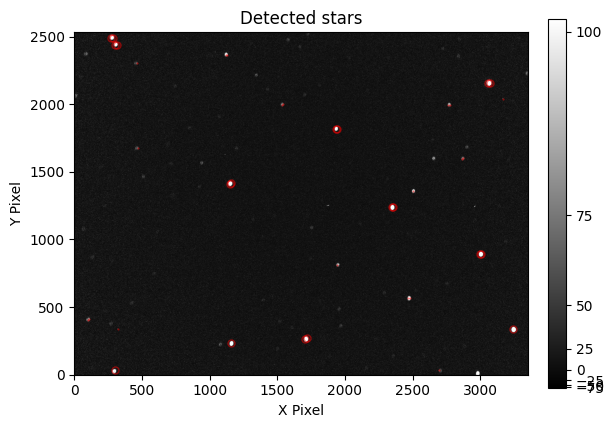

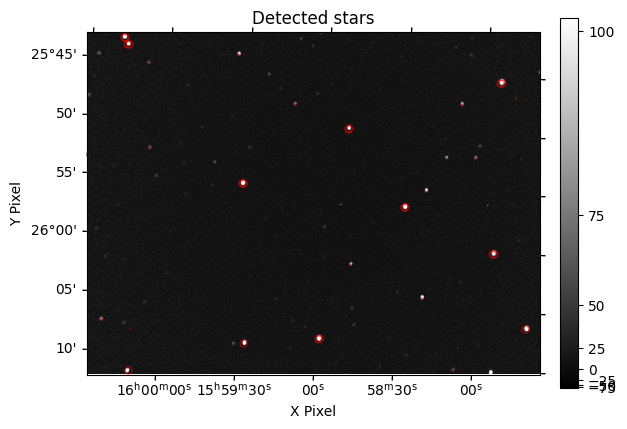

In [12]:
# %load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import pandas as pd
wcs = WCS(fits.getheader("/Volumes/labt1/gavin/LUMOS/results/180524-TCrb--001-30s-...n res/new-image.fits"))
filename = "/Volumes/labt1/gavin/LUMOS/results/180524-TCrb--001-30s-...n res/new-image.fits"
metadata = pd.read_csv('../results/TCrB_metadata.csv')
source = lupho.star_identification(filename, threshold=5.0)
fig = lupho.plot_source_single(fits.getdata(filename), source)
fig2 = lupho.plot_source_single(fits.getdata(filename), source, projection = wcs)
plt.show()

In [3]:
source

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,2697.113193399423,31.88470701177586,0.5390782439245605,0.03502014950237597,0.889971222089434,361,70.7418166638825,10482.707379446187,-10.051183657025591,-0.03730278923535045
2,302.8577029467878,30.781537268764385,0.213907476121924,-0.42938889791317664,0.8828432902188592,361,206.14893934540373,50811.97671311746,-11.764915225954178,-1.308930876253238
3,1156.517554340891,232.20130597415212,0.606912383426312,0.3382937093867219,0.9919346410779023,361,928.1715936408924,153298.84489178052,-12.963847206134378,-2.574459876373173
4,1707.666164184679,265.21993891755426,0.7744174037222236,0.2400225897569486,0.88440020158507,361,3197.0409594362013,468640.5519730089,-14.177099664643585,-3.7646760622764113
5,1718.1257650841662,267.7613630282326,0.4853392179224418,-0.36281108075662694,0.9069543865000412,361,2682.5199460984054,508258.4200330121,-14.26521145520871,-3.775351122193155
6,3240.2532302035747,336.4284708751504,0.7150539409582582,0.3562751507709324,0.9800353421441139,361,1312.67653775182,214735.04995085963,-13.329757343949058,-2.7889228730862756
7,321.8634054103151,340.5025227413319,0.5605273230917298,0.013606880067225883,0.08522731309754503,361,58.850174842870885,884.3703118560845,-7.366585387419641,-0.3222074132714975
8,96.71315081244467,407.5603062223869,0.8403241109368256,0.1940350979189231,0.5849341322037523,361,130.26177583192498,15006.002714977105,-10.440662551723367,-0.35902374821861455
9,110.66456099083044,412.2310944650254,0.45762222762116805,-0.3139922496099506,0.7559437846799609,361,107.91046936901898,18854.724886716805,-10.688550499762812,-0.42303403045704036


In [4]:
from astropy.wcs import WCS, utils
wcs = WCS(fits.getheader("/Volumes/flashlabt/cleaned_FITS/190524-TCrb-004-20s-R_calibrated_clean.fits"))
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 3352  2532


In [ ]:
from astropy.wcs import WCS, utils
wcs = WCS(fits.getheader("/Volumes/labt1/gavin/LUMOS/results/180524-TCrb--001-30s-...n res/new-image.fits"))
print(wcs)
print(wcs.world_axis_physical_types)
source_coords = utils.pixel_to_skycoord(source['xcentroid'], source['ycentroid'], wcs)
source['RA'] = source_coords.ra.degree; source['DEC'] = source_coords.dec.degree
source

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 239.69937952 25.9036851436 
CRPIX : 1986.77017212 1458.05612183 
CD1_1 CD1_2  : -0.000191616910297 1.03497826956e-05 
CD2_1 CD2_2  : -1.02311649652e-05 -0.000191957602842 
NAXIS : 3352  2532
['pos.eq.ra', 'pos.eq.dec']


id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,RA,DEC
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
1,2697.113193399423,31.88470701177586,0.5390782439245605,0.03502014950237597,0.889971222089434,361,70.7418166638825,10482.707379446187,-10.051183657025591,-0.03730278923535045,239.53151243752225,26.169830707850892
2,302.8577029467878,30.781537268764385,0.213907476121924,-0.42938889791317664,0.8828432902188592,361,206.14893934540373,50811.97671311746,-11.764915225954178,-1.308930876253238,240.0429223666206,26.194169228747832
3,1156.517554340891,232.20130597415212,0.606912383426312,0.3382937093867219,0.9919346410779023,361,928.1715936408924,153298.84489178052,-12.963847206134378,-2.574459876373173,239.862612342357,26.147023019545095
4,1707.666164184679,265.21993891755426,0.7744174037222236,0.2400225897569486,0.88440020158507,361,3197.0409594362013,468640.5519730089,-14.177099664643585,-3.7646760622764113,239.74527760326066,26.135133436854957
5,1718.1257650841662,267.7613630282326,0.4853392179224418,-0.36281108075662694,0.9069543865000412,361,2682.5199460984054,508258.4200330121,-14.26521145520871,-3.775351122193155,239.74307261711297,26.134540507245525
6,3240.2532302035747,336.4284708751504,0.7150539409582582,0.3562751507709324,0.9800353421441139,361,1312.67653775182,214735.04995085963,-13.329757343949058,-2.7889228730862756,239.4191570944711,26.105888790232783
7,321.8634054103151,340.5025227413319,0.5605273230917298,0.013606880067225883,0.08522731309754503,361,58.850174842870885,884.3703118560845,-7.366585387419641,-0.3222074132714975,240.04210718668804,26.13465272089938
8,96.71315081244467,407.5603062223869,0.8403241109368256,0.1940350979189231,0.5849341322037523,361,130.26177583192498,15006.002714977105,-10.440662551723367,-0.35902374821861455,240.0909366786391,26.124059212504054
9,110.66456099083044,412.2310944650254,0.45762222762116805,-0.3139922496099506,0.7559437846799609,361,107.91046936901898,18854.724886716805,-10.688550499762812,-0.42303403045704036,240.08800357066488,26.123024831265273


['RA', 'DEC']


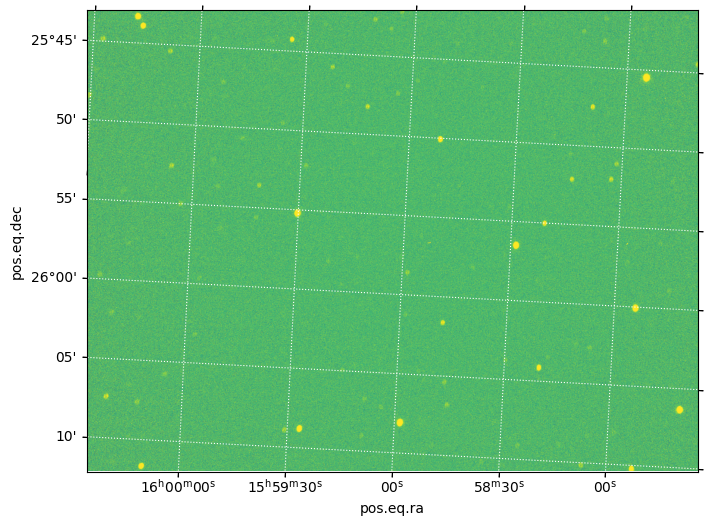

1/1 ╢━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╟               


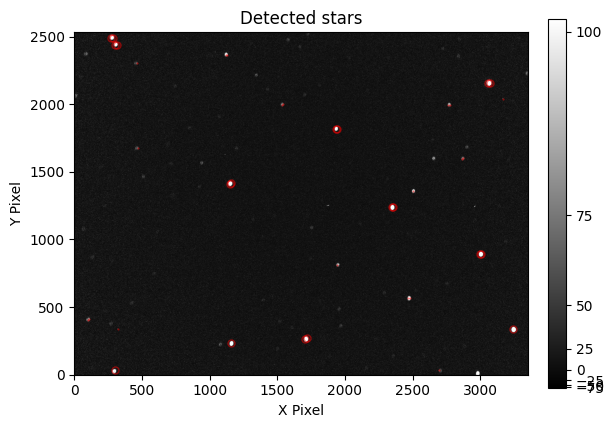

In [5]:
from astropy.io import fits
filename = "/Volumes/labt1/gavin/LUMOS/results/180524-TCrb--001-30s-V/new-image.fits"
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from lumos.visualization import plot_ccd
import lumos.photometry as lupho
science_data = fits.getdata(filename)
wcs = WCS(fits.getheader(filename))
print(wcs.axis_type_names)
norm = simple_norm(science_data, 'sqrt', percent=99)

plt.figure(figsize=(8, 6))
ax = plt.subplot(projection=wcs)
ax.imshow(science_data, norm=norm)
# ax.set_xlabel('RA (J2000)')
# ax.set_ylabel('Dec (J2000)')
plt.grid(color='white', ls='dotted')
plt.show()

source = lupho.star_identification(filename, threshold=5.0)
fig = lupho.plot_source_single(science_data, source)

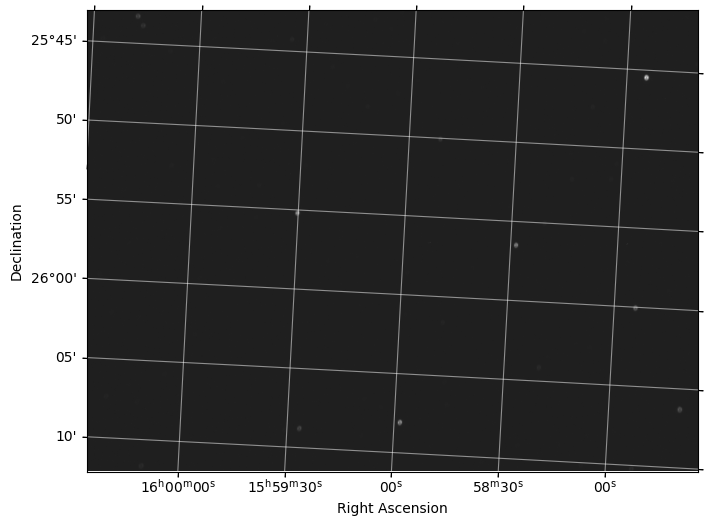

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io import fits

hdul = fits.open("../results/cleaned_FITS/180524-TCrb--001-30s-V_calibrated_clean.fits")
data = hdul[0].data
header = hdul[0].header

# WCS that maps pixels -> RA/Dec
w = WCS(header)

fig, ax = plt.subplots(subplot_kw={'projection': w}, figsize=(8, 6))
# ax = fig.add_subplot(projection=w)   # <-- WCSAxes

# draw the image using the WCSAxes "pixel" transform so image pixels map correctly
# transformation = ax.get_transform('pixel')
ax.imshow(data, origin='lower', cmap = "gray")

# Now overlay pixel-style labels (optional) and RA/Dec grid (main coords)
ax.set_xlabel('RA')   # optional; note these are WCSAxes but we can label as pixels

ax.coords.grid(color='white', alpha=0.5, linestyle='solid')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
# ax.grid(True, color='red', linestyle=':', alpha=0.7) 
# RA/Dec grid is the main coordinate system for this axis (because projection=w)
# ax.coords.grid(color='white', ls=':')
# ax.coords[0].set_axislabel('RA')
# ax.coords[1].set_axislabel('Dec')
hdul.close()
plt.show()

In [3]:
from astropy.wcs import WCS
print(metadata['CLN_FILENAME'][1])
with fits.open(metadata['CLN_FILENAME'][1]) as hdul:
    wcs = WCS(hdul[0].header)
    print(wcs)
    print(wcs.world_axis_physical_types)

../results/cleaned_FITS/180524-TCrb--001-30s-V_calibrated_clean.fits
WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 3352  2532
[None, None]


this is bad, we have no WCS data whatsoever. Plan B: manual

In [2]:
from astropy.io import fits

# Load your science (background-subtracted) image
rawname = "/Volumes/labt1/gavin/.brin/Fotometri_Timau_2024/180524/180524-TCrb--001-30s-V.fit"
science_hdu = fits.open(rawname)
science_data = science_hdu[0].data
science_header = science_hdu[0].header

from astropy.wcs import WCS

# Load WCS solution from Astrometry.net
wcs_hdu = fits.open('/Volumes/labt1/gavin/LUMOS/results/180524-TCrb--001-30s-...n res/wcs.fits')
wcs_solution = WCS(wcs_hdu[0].header)

# Copy WCS keywords into your science header
science_header.update(wcs_solution.to_header())

# Optionally, save a new WCS-calibrated version
science_hdu[0].header = science_header
science_hdu.writeto('/Volumes/labt1/gavin/.brin/Fotometri_Timau_2024/180524/180524-TCrb--001-30s-V.fit', overwrite=True)
